# 07 · Interpret the source mechanism before real evaluation

**Goal:** inspect measured lesson utilities and source-held selection
performance before committing to the real transfer experiment.

**Question:** can a short training response tell us which synthetic lesson
will improve an unfamiliar pose estimator on real video?

The source sequence is **00 → 01 → 02 → 03 → 07**. Run 02 once per configured
source student. After the source decision, prepare independent GAVD references
in 04, deploy without reading their labels in 05, and exchange selected lessons
in 08. Explicitly evaluate in 06. These notebooks contain no precomputed
research results or substitute models.

[Proposal](../../../../../../notes/research-agenda/proposals/synthetic-training-selection.md)
· [Notebook guide](../../../../../../notebooks/synthetic_training/README.md)
· [HAIC setup and launch commands](../../../../../../slurm/synthetic-training/README.md)

In [1]:
from pathlib import Path
import json
import os
import sys
from time import perf_counter

root_override = os.environ.get("GAVD6_ROOT")
candidates = ([Path(root_override).expanduser()] if root_override else
              [Path.cwd(), *Path.cwd().parents])
PROJECT_ROOT = next((p.resolve() for p in candidates
                     if (p / "src/gavd6_sjepa").is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Set GAVD6_ROOT to the gavd6 checkout.")
sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.chdir(PROJECT_ROOT)
os.environ.setdefault("GAVD6_ROOT", str(PROJECT_ROOT))
os.environ.setdefault("PYOPENGL_PLATFORM", "egl")

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, SVG, display
from gavd6_sjepa.research_directions.synthetic_training.config import RunConfig
from gavd6_sjepa.research_directions.synthetic_training import workflow

cfg = RunConfig.from_env()
RUN_ROOT = cfg.root
get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams.update({"figure.figsize": (9, 4), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})

def show_result(result):
    # Display the tables and artifact paths returned by a workflow stage.
    if isinstance(result, pd.DataFrame):
        display(result)
    elif isinstance(result, dict):
        for name, value in result.items():
            display(Markdown(f"### {name.replace('_', ' ')}"))
            if isinstance(value, pd.DataFrame):
                display(value)
            elif isinstance(value, Path) and value.suffix == ".svg" and value.is_file():
                display(SVG(filename=str(value)))
            else:
                print(json.dumps(value, indent=2, default=str) if isinstance(value, (list, dict)) else value)
    else:
        print(result)

print(f"Run: {RUN_ROOT}")
print(f"Context representation: {cfg.context_kind}; device: {cfg.device}")

Run: /hai/scratch/tedmui/alexpose/experiments/sjepa/gavd6/outputs/synthetic-training/pilot-01
Context representation: vjepa; device: cuda


## 1. Ask whether there is useful information to learn

This report uses source trial outcomes and the source-validation
comparison only. It does not read independent GAVD landmark outcomes.

Look for differences in which lesson works best, useful achieved gain
over replay, and a gap between selected gain and the best available
lesson. The latter gap is **regret**. An oracle uses every lesson's
reference outcome and is a diagnostic, not a deployment method.

### selection

{
  "budget": 75,
  "primary_comparator": "domain",
  "best_fixed": "front",
  "methods": {
    "before": {
      "kind": "nearest",
      "parameter": 1.0,
      "validation_error": 0.027025762386308137
    },
    "after": {
      "kind": "nearest",
      "parameter": 1.0,
      "validation_error": 0.027025762386308137
    },
    "response": {
      "kind": "nearest",
      "parameter": 1.0,
      "validation_error": 0.02702220227058258
    },
    "source_progress": {
      "kind": "nearest",
      "parameter": 1.0,
      "validation_error": 0.027025762386308137
    },
    "full": {
      "kind": "nearest",
      "parameter": 1.0,
      "validation_error": 0.02702647999854117
    },
    "magnitude": {
      "kind": "nearest",
      "parameter": 1.0,
      "validation_error": 0.027025762386308137
    },
    "weakness": {
      "kind": "nearest",
      "parameter": 5.0,
      "validation_error": 0.026937256984499655
    },
    "domain": {
      "kind": "nearest",
      "parameter": 3.0,

### source matrix

action,balanced,blur,front,full_replay,low_resolution,low_resolution_occlusion,oblique,occlusion,pooled,replay,side
student_id,,,,,,,,,,,
hrnet_w32,0.052191,0.052161,0.052174,0.052146,0.052174,0.052163,0.052168,0.052177,0.052170,0.052157,0.052190
hrnet_w48,0.027215,0.027238,0.027232,0.027247,0.027214,0.027209,0.027218,0.027238,0.027217,0.027239,0.027217
rtmpose_m,0.060053,0.059807,0.059219,0.061222,0.061043,0.060433,0.060044,0.060317,0.060042,0.060985,0.060121
rtmpose_s,0.026916,0.026919,0.026566,0.027383,0.026537,0.027195,0.026728,0.027124,0.026857,0.027402,0.026760


### validation

,view,kind,parameter,budget,error,regret
2,domain,nearest,3.0,75,0.026781,0.000116
9,simple_context,nearest,3.0,75,0.026842,0.000177
4,image_context,nearest,1.0,75,0.026847,0.000182
11,weakness,nearest,5.0,75,0.026937,0.000272
6,no_context,nearest,5.0,75,0.026942,0.000277
7,response,nearest,1.0,75,0.027022,0.000357
0,after,nearest,1.0,75,0.027026,0.000361
1,before,nearest,1.0,75,0.027026,0.000361
10,source_progress,nearest,1.0,75,0.027026,0.000361
5,magnitude,nearest,1.0,75,0.027026,0.000361


### report

/hai/scratch/tedmui/alexpose/experiments/sjepa/gavd6/outputs/synthetic-training/pilot-01/reports/README.md


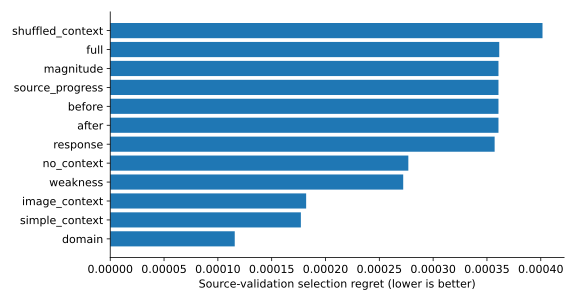

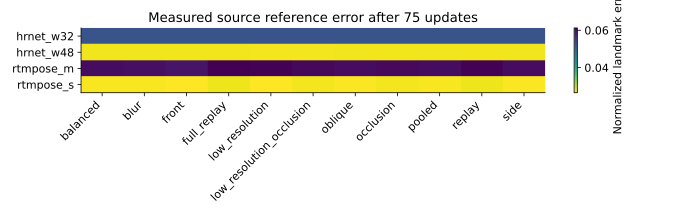

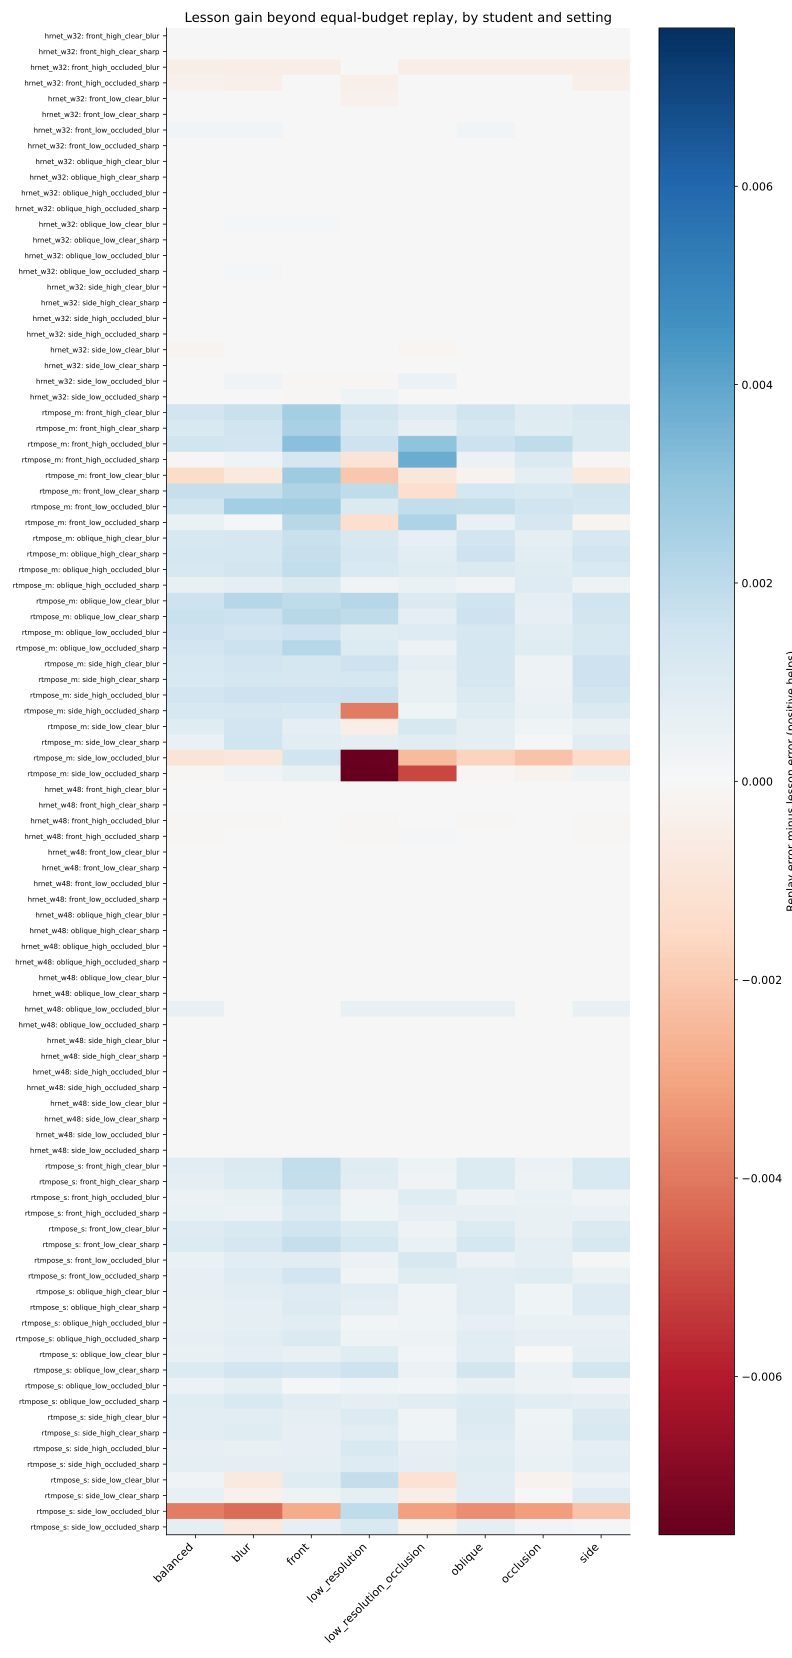

In [2]:
report = workflow.report(cfg)
show_result(report)
for figure in sorted((RUN_ROOT / "reports").glob("*.svg")):
    display(SVG(filename=str(figure)))

## 2. Challenge a promising-looking table

A response can encode the model family, learning rate, or overall update
size. The primary matched source-progress control asks whether changes
on the target clips add information beyond those simpler explanations.
Read per-student results, not only a pooled average across domain rows.

A useful model-specific teaching effect requires good decisions, not
accurate prediction of one student's overall gain scale. Compare
response-informed and response-free selectors with matched capacity,
source database, budget, and context features.

If every selector chooses replay, the rejection option worked but
useful synthetic teaching has not been demonstrated. If one fixed
lesson wins almost everywhere, prioritize that simple explanation.

## 3. Make a bounded continuation decision

Continue when lessons offer useful varied gains and the frozen teacher
selects them better than strong simple controls on excluded source
students. Source success is still not evidence of real GAVD transfer.

A few checkpoints provide a feasibility result, not a population of
learning behaviors. Expand independent students and settings only after
measuring throughput and seeing a usable signal. Keep held-architecture
outcomes out of source fitting throughout.

If proceeding, start [04 · Prepare real evaluation](../../../../../../notebooks/synthetic_training/04_prepare_real_evaluation.ipynb).
The [proposal](../../../../../../notes/research-agenda/proposals/synthetic-training-selection.md)
defines the claims that each comparison can support.